# Part 3 — Full-Image Transfer Learning

This notebook implements **full-image** sentiment classification using a **frozen pre-trained backbone**
as a feature extractor, with a custom classification head trained on top.

### Prerequisites — the following files must be in your Google Drive:
| File | Where it comes from |
|------|--------------------|
| `train_ende.zip` | MSCTD dataset (original) |
| `dev.zip` | MSCTD dataset (original) |
| `test.zip` | MSCTD dataset (original) |
| `sentiment_train.txt` | MSCTD labels |
| `sentiment_dev.txt` | MSCTD labels |
| `sentiment_test.txt` | MSCTD labels |

### What this notebook does:
1. Loads the original full-resolution MSCTD images (no face cropping)
2. Extracts image-level features using a **frozen** ResNet-50 backbone
3. Trains a custom multi-layer classification head for 3-class sentiment
4. Reports **Accuracy**, **F1-score**, and **Confusion Matrix** on the test set
5. Saves model weights and figures to Drive ready for Part 4 fusion

**Run cells in order from top to bottom.**

In [1]:
# CELL 1 — Mount Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn timm
!pip install --upgrade --force-reinstall "Pillow<10"
print('Setup complete.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Pillow: filename=Pillow-9.5.0-cp312-cp312-linux_x86_64.whl size=1210281 sha256=af8f5c65e378ed0b6e7f923b3b5151412fc81b3d5f63bbd34991f25103c1038a
  Stored in directory: /root/.cache/pip/wheels/ea/de/2e/75a6399e5d8cd3a55c13c8f0658d996d4ce4cff37389de044c
Successfully built Pillow
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


Setup complete.


In [1]:
# CELL 2 — Unzip original dataset images onto Colab disk
#
# Adjust DRIVE_AML below if your zips are in a different Drive folder.
import os, glob

DRIVE_ROOT = '/content/drive/MyDrive'      # model weights + output figures saved here
DRIVE_AML  = '/content/drive/MyDrive/AML'  # label .txt files + dataset zips

def find_zip(name):
    for pattern in [
        f'{DRIVE_ROOT}/{name}',
        f'{DRIVE_AML}/{name}',
        f'{DRIVE_ROOT}/**/{name}',
    ]:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return hits[0]
    return None

DATA_DIR = '/content/dataset'
os.makedirs(DATA_DIR, exist_ok=True)

splits = [
    ('train', 'train_ende.zip', f'{DATA_DIR}/train_ende'),
    ('dev',   'dev.zip',        f'{DATA_DIR}/dev'),
    ('test',  'test.zip',       f'{DATA_DIR}/test'),
]

for split, zip_name, target_dir in splits:
    if not os.path.exists(target_dir):
        zip_path = find_zip(zip_name)
        if zip_path:
            print(f'Unzipping {zip_name} ...')
            os.system(f'unzip -q "{zip_path}" -d {DATA_DIR}/')
            print(f'  → {target_dir}')
        else:
            raise FileNotFoundError(
                f'Could not find {zip_name} on Drive.\n'
                f'Please upload it to MyDrive or MyDrive/AML/ and re-run.'
            )
    else:
        print(f'{split}: already on disk.')

print('\nDataset folders:', os.listdir(DATA_DIR))

Unzipping train_ende.zip ...
  → /content/dataset/train_ende
Unzipping dev.zip ...
  → /content/dataset/dev
Unzipping test.zip ...
  → /content/dataset/test

Dataset folders: ['dev', 'train_ende', 'test']


In [2]:
# CELL 3 — All imports and global config
import os, random, copy, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Label mapping (same convention as Parts 1 & 2) ───────────────────────────
LABEL_MAP   = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
NUM_CLASSES = 3

# ── File paths ────────────────────────────────────────────────────────────────
# Adjust LABELS_ROOT if your .txt files are stored elsewhere on Drive.
LABELS_ROOT = '/content/drive/MyDrive/AML'
LABEL_TRAIN = f'{LABELS_ROOT}/sentiment_train.txt'
LABEL_DEV   = f'{LABELS_ROOT}/sentiment_dev.txt'
LABEL_TEST  = f'{LABELS_ROOT}/sentiment_test.txt'

# Original full images (unzipped in Cell 2)
IMG_TRAIN   = '/content/dataset/train_ende'
IMG_DEV     = '/content/dataset/dev'
IMG_TEST    = '/content/dataset/test'

# ── Training hyper-parameters ─────────────────────────────────────────────────
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 3e-4
WEIGHT_DECAY= 1e-4
IMG_SIZE    = 224      # required by ResNet-50 / ViT / Swin

# ── ImageNet normalisation (required for pre-trained backbones) ────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

print('Config OK.')

Device: cpu
Config OK.


In [3]:
# CELL 4 — Helper: discover image folder layout
#
# MSCTD stores images in one of two ways:
#   a)  split_folder/image_index.jpg   (flat)
#   b)  split_folder/images/image_index.jpg  (sub-folder)
# This helper finds the right directory automatically.

def find_image_dir(base_dir):
    """Return the directory that actually contains .jpg files."""
    for candidate in [base_dir,
                      os.path.join(base_dir, 'images'),
                      os.path.join(base_dir, 'image')]:
        if os.path.isdir(candidate):
            imgs = [f for f in os.listdir(candidate)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if imgs:
                return candidate
    # Fall back: search recursively for the deepest folder with images
    for root, _, files in os.walk(base_dir):
        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
            return root
    raise FileNotFoundError(f'No image files found under {base_dir}')

IMG_TRAIN_DIR = find_image_dir(IMG_TRAIN)
IMG_DEV_DIR   = find_image_dir(IMG_DEV)
IMG_TEST_DIR  = find_image_dir(IMG_TEST)

print(f'Train images : {IMG_TRAIN_DIR}')
print(f'Dev images   : {IMG_DEV_DIR}')
print(f'Test images  : {IMG_TEST_DIR}')

# Quick sanity check
for split, d, lfile in [
    ('train', IMG_TRAIN_DIR, LABEL_TRAIN),
    ('dev',   IMG_DEV_DIR,   LABEL_DEV),
    ('test',  IMG_TEST_DIR,  LABEL_TEST),
]:
    n_imgs   = len([f for f in os.listdir(d)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    n_labels = sum(1 for _ in open(lfile) if _.strip())
    match    = '✓' if n_imgs == n_labels else f'⚠ MISMATCH ({n_imgs} imgs vs {n_labels} labels)'
    print(f'  {split}: {n_imgs} images, {n_labels} labels  {match}')

Train images : /content/dataset/train_ende
Dev images   : /content/dataset/dev
Test images  : /content/dataset/test
  train: 20240 images, 20240 labels  ✓
  dev: 5063 images, 5063 labels  ✓
  test: 5067 images, 5067 labels  ✓


In [4]:
# CELL 5 — Dataset class: loads full images indexed by label file row

class FullImageDataset(Dataset):
    """
    Loads the i-th image from img_dir to match the i-th label in label_file.
    Images are sorted by numeric filename stem so ordering matches the labels.
    """
    def __init__(self, img_dir, label_file, transform):
        self.img_dir   = img_dir
        self.transform = transform

        # Sort filenames numerically (e.g. 0.jpg < 10.jpg < 100.jpg)
        all_files = [
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.images = sorted(
            all_files,
            key=lambda x: int(os.path.splitext(x)[0]) if os.path.splitext(x)[0].isdigit() else x
        )

        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]

        assert len(self.images) == len(self.labels), (
            f'Image count ({len(self.images)}) != label count ({len(self.labels)}) in {img_dir}'
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            # Corrupted image → return a black placeholder
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        return self.transform(img), self.labels[idx]


# ── Transforms ─────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = FullImageDataset(IMG_TRAIN_DIR, LABEL_TRAIN, train_tf)
dev_ds   = FullImageDataset(IMG_DEV_DIR,   LABEL_DEV,   eval_tf)
test_ds  = FullImageDataset(IMG_TEST_DIR,  LABEL_TEST,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Datasets ready — Train: {len(train_ds)}, Dev: {len(dev_ds)}, Test: {len(test_ds)}')

Datasets ready — Train: 20240, Dev: 5063, Test: 5067


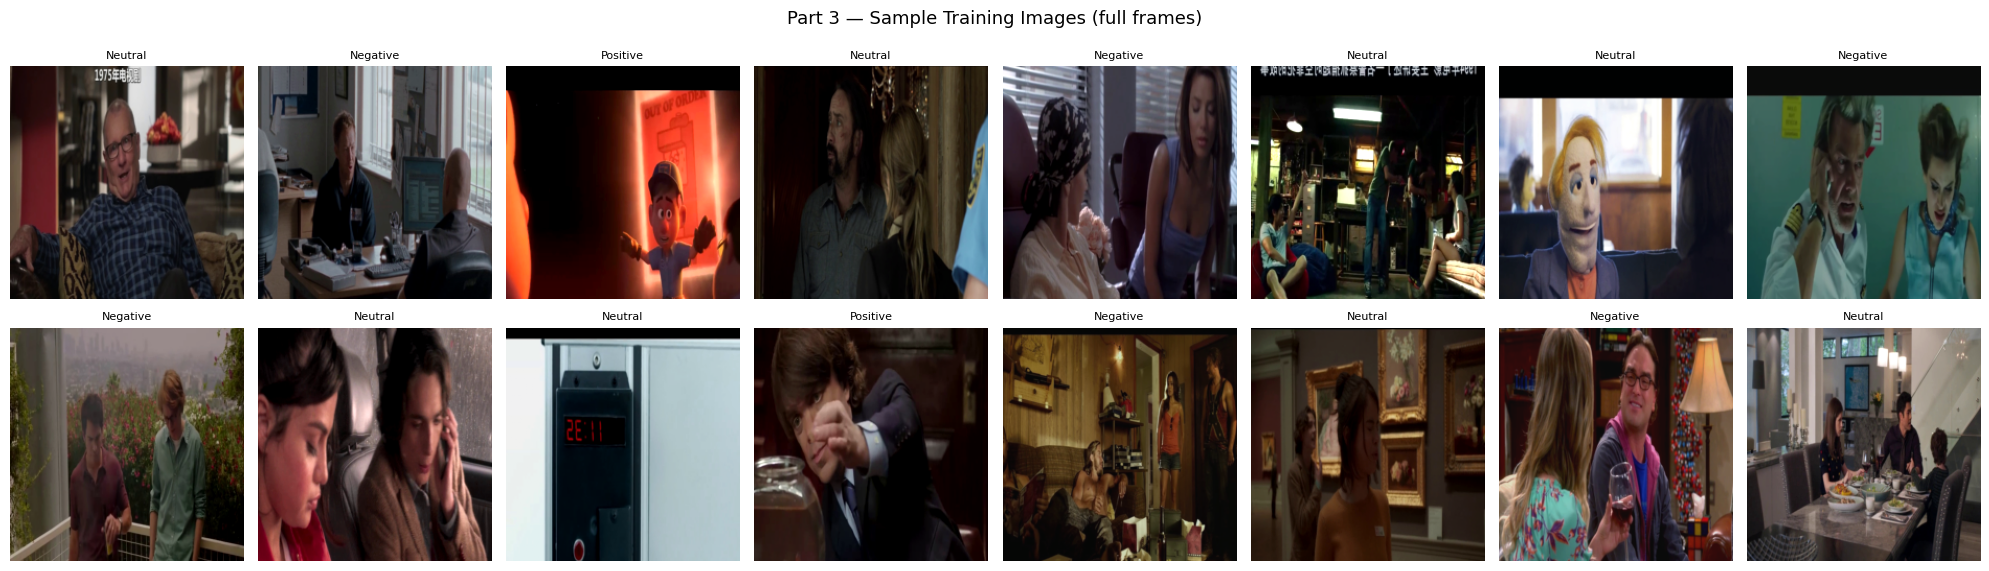

Saved to Drive.


In [5]:
# CELL 6 — Visualise a batch of training images

inv_norm = transforms.Normalize(
    mean=[-m / s for m, s in zip(MEAN, STD)],
    std =[1.0 / s for s in STD]
)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, img, lbl in zip(axes.flatten(), imgs[:16], labels[:16]):
    img_show = inv_norm(img).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(LABEL_MAP[lbl.item()], fontsize=8)
    ax.axis('off')
plt.suptitle('Part 3 — Sample Training Images (full frames)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/sample_images_part3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [6]:
# CELL 7 — Model: frozen ResNet-50 backbone + custom classification head
#
# Per the project spec (Part 3 constraint):
#   "The weights of the pre-trained feature extraction backbone must remain frozen."
#
# Architecture summary:
#   ResNet-50 (frozen, ImageNet weights)  →  2048-d feature vector
#   → BN → FC(2048→512) → ReLU → Dropout(0.4)
#   → BN → FC(512→128)  → ReLU → Dropout(0.3)
#   → FC(128→3)   (no softmax — CrossEntropyLoss handles it)

class FullImageClassifier(nn.Module):
    def __init__(self, num_classes=3, dropout1=0.4, dropout2=0.3):
        super().__init__()

        # ── Frozen backbone ───────────────────────────────────────────────────
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.feature_dim = backbone.fc.in_features   # 2048
        backbone.fc = nn.Identity()                  # remove original head
        self.backbone = backbone

        for param in self.backbone.parameters():     # FREEZE all backbone weights
            param.requires_grad = False

        # ── Trainable classification head ─────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(self.feature_dim),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout1),
            nn.BatchNorm1d(512),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)   # (B, 2048)
        return self.classifier(features)  # (B, num_classes)


model = FullImageClassifier(num_classes=NUM_CLASSES).to(device)

# Verify only the head trains
total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f'Backbone   : ResNet-50 (ImageNet V2 weights) — FROZEN')
print(f'Feature dim: {model.feature_dim}')
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}  (classification head only)')
print(f'Frozen params   : {frozen_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 355MB/s]


Backbone   : ResNet-50 (ImageNet V2 weights) — FROZEN
Feature dim: 2048
Total params    : 24,628,291
Trainable params: 1,120,259  (classification head only)
Frozen params   : 23,508,032


In [7]:
# CELL 8 — Loss, optimiser, and LR scheduler
#
# We optimise only the classification head parameters.
# A cosine annealing scheduler gradually lowers LR to avoid overshooting.

# Compute per-class weights to handle class imbalance
from collections import Counter

label_counts = Counter(train_ds.labels)
total        = len(train_ds)
class_weights= torch.tensor(
    [total / (NUM_CLASSES * label_counts[c]) for c in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)
print('Class weights:', {LABEL_MAP[i]: f'{class_weights[i]:.3f}' for i in range(NUM_CLASSES)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'Optimiser: AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}')
print(f'Scheduler: CosineAnnealingLR  T_max={NUM_EPOCHS}')

Class weights: {'Neutral': '0.975', 'Negative': '0.861', 'Positive': '1.230'}
Optimiser: AdamW  lr=0.0003  weight_decay=0.0001
Scheduler: CosineAnnealingLR  T_max=20


In [8]:
# CELL 9 — Training and evaluation helper functions

def run_epoch(model, loader, criterion, optimizer=None, desc=''):
    """Single train or eval pass. Returns (avg_loss, accuracy, predictions, ground_truth)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc=desc, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], max_norm=1.0
                )
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

            all_preds .extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / total
    acc      = correct / total
    return avg_loss, acc, all_preds, all_labels


print('Helper functions defined.')

Helper functions defined.


In [9]:
# CELL 10 — Training loop with early stopping
#
# Trains the classification head for up to NUM_EPOCHS epochs.
# Saves the best checkpoint (by dev accuracy) to Drive.

BEST_MODEL_PATH = f'{DRIVE_ROOT}/best_fullimage_model_part3.pth'
PATIENCE        = 7   # stop if dev accuracy doesn't improve for this many epochs

history = {'train_loss': [], 'train_acc': [], 'dev_loss': [], 'dev_acc': []}
best_dev_acc  = 0.0
epochs_no_imp = 0

print(f'Training for up to {NUM_EPOCHS} epochs  (early-stop patience={PATIENCE})\n')
print(f'{"Epoch":<6} {"Train Loss":>11} {"Train Acc":>10} {"Dev Loss":>10} {"Dev Acc":>9} {"LR":>10}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer,
                                    desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]')
    d_loss, d_acc, _, _ = run_epoch(model, dev_loader, criterion,
                                    desc=f'Epoch {epoch}/{NUM_EPOCHS} [dev]')
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(t_loss)
    history['train_acc' ].append(t_acc)
    history['dev_loss'  ].append(d_loss)
    history['dev_acc'   ].append(d_acc)

    flag = ''
    if d_acc > best_dev_acc:
        best_dev_acc = d_acc
        best_state   = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_MODEL_PATH)
        flag = '  ← best'
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1

    print(f'{epoch:<6} {t_loss:>11.4f} {t_acc:>10.4f} {d_loss:>10.4f} {d_acc:>9.4f} {current_lr:>10.2e}{flag}')

    if epochs_no_imp >= PATIENCE:
        print(f'\nEarly stopping — no improvement for {PATIENCE} epochs.')
        break

print(f'\nBest dev accuracy: {best_dev_acc:.4f}')
print(f'Best model saved to: {BEST_MODEL_PATH}')

Training for up to 20 epochs  (early-stop patience=7)

Epoch   Train Loss  Train Acc   Dev Loss   Dev Acc         LR
-----------------------------------------------------------------


1           1.1102     0.3562     1.1051    0.3472   2.98e-04  ← best


2           1.0859     0.3966     1.1046    0.3567   2.93e-04  ← best


3           1.0699     0.4259     1.1176    0.3403   2.84e-04


KeyboardInterrupt: 

In [1]:
# CELL 11 — Plot training curves

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(epochs_ran, history['dev_loss'],   label='Dev',   marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Part 3 — Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o', markersize=4)
axes[1].plot(epochs_ran, history['dev_acc'],   label='Dev',   marker='s', markersize=4)
axes[1].axhline(best_dev_acc, color='green', linestyle='--', linewidth=1,
                label=f'Best dev acc = {best_dev_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Part 3 — Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Part 3 — Full-Image Transfer Learning: Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/training_curves_part3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

NameError: name 'history' is not defined

In [ ]:
# CELL 12 — Load best checkpoint and evaluate on test set

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
print(f'Loaded best checkpoint from: {BEST_MODEL_PATH}\n')

test_loss, test_acc, test_preds, test_labels = run_epoch(
    model, test_loader, criterion, desc='Test evaluation'
)

macro_f1    = f1_score(test_labels, test_preds, average='macro')
weighted_f1 = f1_score(test_labels, test_preds, average='weighted')

print('=' * 50)
print('PART 3 — TEST SET RESULTS')
print('=' * 50)
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')
print(f'  Test Loss    : {test_loss:.4f}')

In [ ]:
# CELL 13 — Full classification report (per-class precision, recall, F1)

print('\nPer-Class Classification Report:')
print('=' * 55)
print(classification_report(
    test_labels, test_preds,
    target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]
))

In [ ]:
# CELL 14 — Confusion matrix

cm          = confusion_matrix(test_labels, test_preds)
class_names = [LABEL_MAP[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title(
    f'Confusion Matrix — Part 3 (ResNet-50 frozen backbone)\n'
    f'Test set  |  Accuracy: {test_acc:.3f}  |  Macro F1: {macro_f1:.3f}',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/confusion_matrix_part3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [ ]:
# CELL 15 — Visualise sample test predictions
#
# Green title = correct prediction, Red title = incorrect.

model.eval()
sample_imgs, sample_labels = [], []
sample_preds = []

with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device))
        preds  = logits.argmax(1).cpu()
        sample_imgs.extend(imgs[:16])
        sample_labels.extend(labels[:16].tolist())
        sample_preds.extend(preds[:16].tolist())
        if len(sample_imgs) >= 16:
            break

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, img, true_lbl, pred_lbl in zip(
    axes.flatten(), sample_imgs[:16], sample_labels[:16], sample_preds[:16]
):
    img_show = inv_norm(img).clamp(0, 1).permute(1, 2, 0).numpy()
    correct  = (true_lbl == pred_lbl)
    ax.imshow(img_show)
    ax.set_title(
        f'True: {LABEL_MAP[true_lbl]}\nPred: {LABEL_MAP[pred_lbl]} {chr(10003) if correct else chr(10007)}',
        color='green' if correct else 'red',
        fontsize=8
    )
    ax.axis('off')

plt.suptitle('Part 3 — Sample Test Predictions (Full Image)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/sample_predictions_part3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [ ]:
# CELL 16 — Save softmax probability scores for Part 4 fusion
#
# Part 4 will combine face-model probs (Part 1/2) + full-image probs (Part 3).
# We save the raw softmax outputs over the full test set as a numpy array.

import json

model.eval()
all_probs, all_true = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Extracting test probs'):
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_true .extend(labels.tolist())

# Also save dev set probs (useful for fusion calibration in Part 4)
dev_probs, dev_true = [], []
with torch.no_grad():
    for imgs, labels in tqdm(dev_loader, desc='Extracting dev probs'):
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        dev_probs.extend(probs.tolist())
        dev_true .extend(labels.tolist())

# Save to Drive
np.save(f'{DRIVE_ROOT}/part3_test_probs.npy',  np.array(all_probs))
np.save(f'{DRIVE_ROOT}/part3_test_labels.npy', np.array(all_true))
np.save(f'{DRIVE_ROOT}/part3_dev_probs.npy',   np.array(dev_probs))
np.save(f'{DRIVE_ROOT}/part3_dev_labels.npy',  np.array(dev_true))

print('Softmax probs saved:')
print(f'  part3_test_probs.npy  — shape {np.array(all_probs).shape}')
print(f'  part3_dev_probs.npy   — shape {np.array(dev_probs).shape}')
print('These are needed by Part 4 for the fusion model.')

In [ ]:
# CELL 17 — (Optional) t-SNE visualisation of extracted features
#
# Projects the 2048-d backbone features down to 2D to show class separation.
# This makes a nice figure for your report.

from sklearn.manifold import TSNE

model.eval()
feat_list, lbl_list = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Extracting features for t-SNE'):
        feats = model.backbone(imgs.to(device)).cpu().numpy()
        feat_list.extend(feats.tolist())
        lbl_list .extend(labels.tolist())

feat_arr = np.array(feat_list)
lbl_arr  = np.array(lbl_list)

# Use a random subset to keep t-SNE fast (max 2000 samples)
max_samples = 2000
if len(feat_arr) > max_samples:
    idx      = np.random.choice(len(feat_arr), max_samples, replace=False)
    feat_arr = feat_arr[idx]
    lbl_arr  = lbl_arr[idx]

print(f'Running t-SNE on {len(feat_arr)} samples ...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
emb    = tsne.fit_transform(feat_arr)

colors = ['#4c72b0', '#dd8452', '#55a868']
fig, ax = plt.subplots(figsize=(9, 7))
for cls_idx, (cls_name, color) in enumerate(zip(
    [LABEL_MAP[i] for i in range(NUM_CLASSES)], colors
)):
    mask = lbl_arr == cls_idx
    ax.scatter(emb[mask, 0], emb[mask, 1], c=color, label=cls_name,
               alpha=0.6, s=10, linewidths=0)
ax.set_title('t-SNE of ResNet-50 Features (test set)', fontsize=13)
ax.legend(markerscale=3)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/tsne_features_part3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [ ]:
# CELL 18 — Final summary

print('=' * 60)
print('PART 3 — FULL-IMAGE TRANSFER LEARNING — FINAL RESULTS')
print('=' * 60)
print()
print('── Architecture ─────────────────────────────────────────────')
print(f'  Backbone       : ResNet-50 (ImageNet V2)  — FROZEN')
print(f'  Feature dim    : {model.feature_dim}')
print(f'  Head           : BN → FC(2048→512) → ReLU → Drop(0.4)')
print(f'                   BN → FC(512→128)  → ReLU → Drop(0.3)')
print(f'                   FC(128→3)')
print(f'  Trainable params: {trainable_params:,}')
print()
print('── Training ─────────────────────────────────────────────────')
print(f'  Epochs run     : {len(history["train_loss"])}')
print(f'  Best dev acc   : {best_dev_acc:.4f}')
print(f'  Optimiser      : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'  Scheduler      : CosineAnnealingLR')
print(f'  Class weights  : balanced')
print()
print('── Test Performance ─────────────────────────────────────────')
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')
print()
print('── Files saved to Drive ─────────────────────────────────────')
print('  best_fullimage_model_part3.pth    ← needed for Part 4 fusion')
print('  part3_test_probs.npy              ← softmax probs for Part 4')
print('  part3_dev_probs.npy               ← softmax probs for Part 4')
print('  training_curves_part3.png         ← include in report')
print('  confusion_matrix_part3.png        ← include in report')
print('  sample_predictions_part3.png      ← include in report')
print('  tsne_features_part3.png           ← include in report (optional)')